In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

In [2]:
trajectory = pd.read_csv("../trajectory/pedestrian_positions_20251124_064305.csv")
# pd.read_csv('pedestrian_positions_20251124_064305.csv')

trajectory = trajectory[['x', 'y']]

trajectory.head()

# Drop first 3500 rows
trajectory_drop = trajectory.iloc[3500::10]
trajectory_drop.head()

,x,y
3500,-1.5,-3.0
3510,-1.5,-3.0
3520,-1.5,-3.0
3530,-1.5,-3.0
3540,-1.5,-3.0


In [3]:
trajectory_drop.describe()

,x,y
count,565.000000,565.000000
mean,-2.678942,-2.542754
std,1.863208,0.959648
min,-5.658000,-4.080000
25%,-4.666000,-3.698000
50%,-2.789000,-1.751000
75%,-0.564000,-1.708000
max,-0.564000,-1.216000


<Axes: xlabel='x', ylabel='y'>

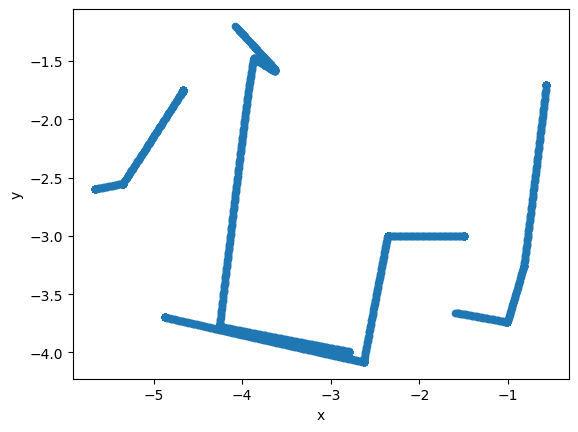

In [4]:
trajectory.plot.scatter(x='x', y='y')

<Axes: xlabel='x', ylabel='y'>

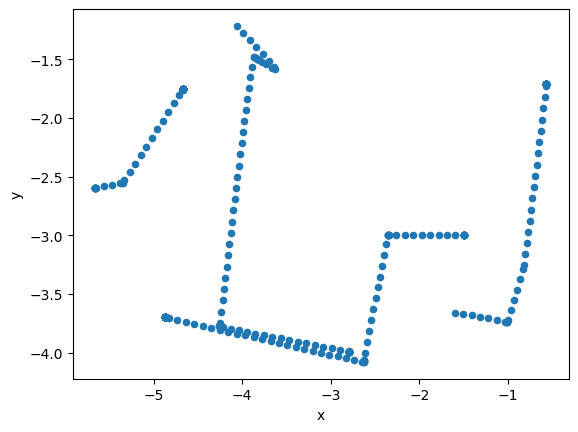

In [5]:
trajectory_drop.plot.scatter(x='x', y='y')

  Cluster 0: center at [-1.52123077 -3.        ]
  Cluster 1: center at [-2.33281818 -3.02254545]
  Cluster 2: center at [-2.77976471 -4.00492157]
  Cluster 3: center at [-4.229      -3.77753333]
  Cluster 4: center at [-4.871      -3.69901389]
  Cluster 5: center at [-5.63333333 -2.59341667]
  Cluster 6: center at [-4.66804762 -1.75344048]
  Cluster 7: center at [-3.78446667 -1.4996    ]
  Cluster 8: center at [-0.56429016 -1.70978756]


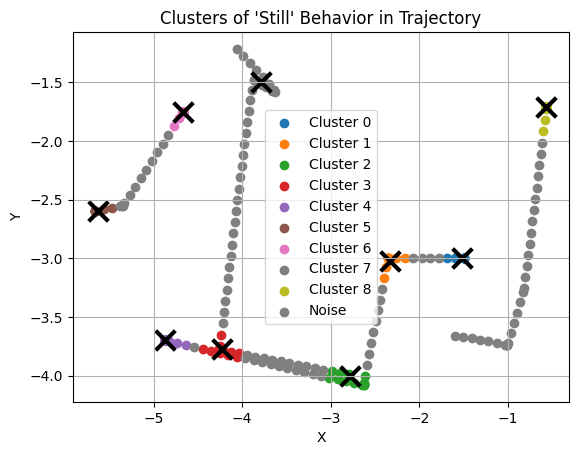

In [6]:
df = trajectory_drop[['x', 'y']].to_numpy()
db = DBSCAN(eps=0.15, min_samples=10).fit(df)

# df = trajectory[['x', 'y']].to_numpy()
# db = DBSCAN(eps=0.15, min_samples=100).fit(df)

labels = db.labels_

# -1 means noise (not in any cluster)
unique_clusters = set(labels) - {-1}
# print("Detected clusters:", unique_clusters)

# Compute cluster centers (where person stays the most)
cluster_centers = {}

for cluster_id in unique_clusters:
    points = df[labels == cluster_id]
    center = points.mean(axis=0)
    cluster_centers[cluster_id] = center

# print("\nCluster centers (likely 'still' locations):")
for cid, ctr in cluster_centers.items():
    print(f"  Cluster {cid}: center at {ctr}")

# ------------------------------------------
# Visualization
# ------------------------------------------
# plt.figure(figsize=(6, 6))

# Plot each cluster
for cluster_id in unique_clusters:
    pts = df[labels == cluster_id]
    plt.scatter(pts[:,0], pts[:,1], label=f"Cluster {cluster_id}")

# Plot noise
noise = df[labels == -1]
if len(noise) > 0:
    plt.scatter(noise[:,0], noise[:,1], color='gray', label='Noise')

# Plot centers
for cid, ctr in cluster_centers.items():
    plt.scatter(ctr[0], ctr[1], marker='x', s=200, linewidths=3, color='black')

plt.legend()
plt.title("Clusters of 'Still' Behavior in Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

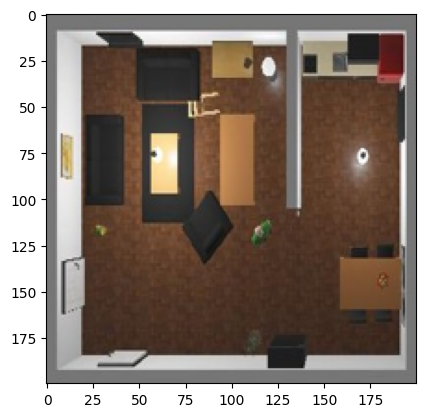

In [7]:
import matplotlib.image as mpimg
from PIL import Image

# Load the image
# Replace 'your_image.png' with the actual path to your image file
img = Image.open('../worlds/.apartment_cropped.jpg') 

# img_temp = img[85:-90,85:-300]

img_temp = img.resize((200,200))
# Display the image
plt.imshow(img_temp)

# Show the plot window
plt.show()

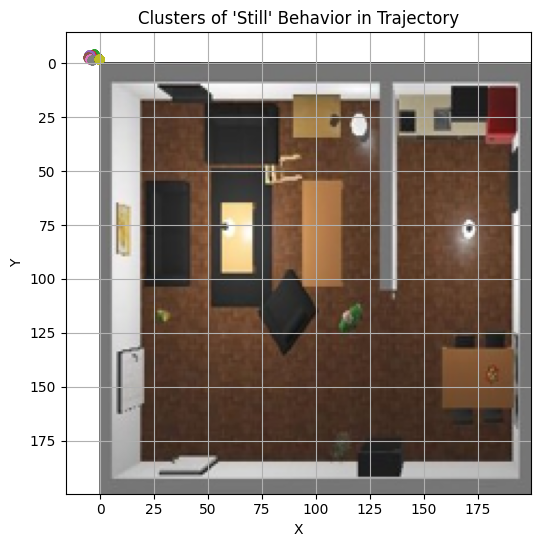

In [8]:
plt.figure(figsize=(6, 6))

# img_temp = img[85:-90,85:-300]

plt.imshow(img_temp)

scale = 1

# Plot each cluster
for cluster_id in unique_clusters:
    pts = df[labels == cluster_id]
    plt.scatter((pts[:,0])*scale + 000, (pts[:,1])*scale + 000, label=f"Cluster {cluster_id}")

# Plot noise
# noise = df[labels == -1]
# if len(noise) > 0:
#     plt.scatter(noise[:,0], noise[:,1], color='gray', label='Noise')

# Plot centers
# for cid, ctr in cluster_centers.items():
#     plt.scatter(ctr[0], ctr[1], marker='x', s=200, linewidths=3, color='black')



# plt.legend()
plt.title("Clusters of 'Still' Behavior in Trajectory")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

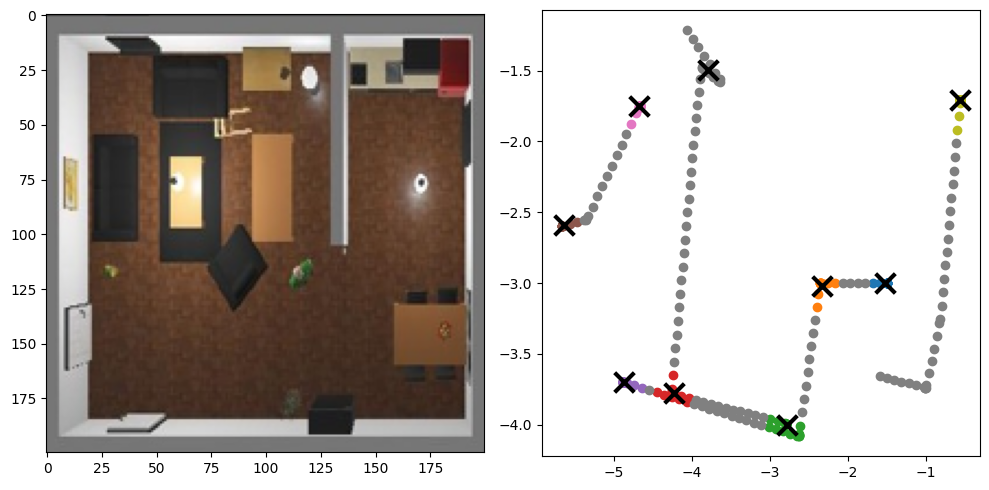

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(img_temp)

# axes[1].set_xlim([-10, 0])  # Adjust as needed for your specific range
# axes[1].set_ylim([-10, 0])

for cluster_id in unique_clusters:
    pts = df[labels == cluster_id]
    ax2.scatter(pts[:,0], pts[:,1], label=f"Cluster {cluster_id}")

# Plot noise
noise = df[labels == -1]
if len(noise) > 0:
    ax2.scatter(noise[:,0], noise[:,1], color='gray', label='Noise')

# Plot centers
for cid, ctr in cluster_centers.items():
    ax2.scatter(ctr[0], ctr[1], marker='x', s=200, linewidths=3, color='black')

# ax1.set_aspect('equal', adjustable='box')
# ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()

# axes[0].set_xlabel('X-axis')

plt.show()


In [15]:
import shutil

destination_file = '../trajectory/center.csv'

with open(destination_file, 'w') as file:
    # Write the new line to the file, including a newline character for formatting
    file.write("x,y\n")
    for cid, ctr in cluster_centers.items():
        x, y = ctr
        sphere_text = f"{x},{y}\n"
        file.write(sphere_text)
        # break